In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("customer_sales_data.csv")

In [3]:
df

,Customer,City,Product,Quantity,Price,Rating
0,Amit,Pune,Laptop,1,60000,5.0
1,Priya,Mumbai,Mobile,2,25000,4.0
2,Rahul,Nashik,Headphones,3,2000,4.0
3,Sneha,Pune,Laptop,1,55000,5.0
4,Amit,Pune,Mouse,4,800,3.0
5,NaN,Mumbai,Keyboard,2,1500,NaN
6,Neha,Nashik,Mobile,1,22000,4.0
7,Rahul,Nashik,Laptop,2,58000,5.0
8,Karan,Pune,Headphones,3,3000,3.0
9,Sneha,Mumbai,Mobile,2,24000,4.0


In [4]:
df.head()

,Customer,City,Product,Quantity,Price,Rating
0,Amit,Pune,Laptop,1,60000,5.0
1,Priya,Mumbai,Mobile,2,25000,4.0
2,Rahul,Nashik,Headphones,3,2000,4.0
3,Sneha,Pune,Laptop,1,55000,5.0
4,Amit,Pune,Mouse,4,800,3.0


In [5]:
df.shape

(10, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Customer  9 non-null      object 
 1   City      10 non-null     object 
 2   Product   10 non-null     object 
 3   Quantity  10 non-null     int64  
 4   Price     10 non-null     int64  
 5   Rating    9 non-null      float64
dtypes: float64(1), int64(2), object(3)
memory usage: 612.0+ bytes


In [7]:
df.isna().sum()

Customer    1
City        0
Product     0
Quantity    0
Price       0
Rating      1
dtype: int64

In [8]:
df[df.isnull().any(axis=1)]

,Customer,City,Product,Quantity,Price,Rating
5,NaN,Mumbai,Keyboard,2,1500,NaN


In [9]:
df["Customer"]=df["Customer"].fillna(df["Customer"].mode()[0])

In [10]:
df

,Customer,City,Product,Quantity,Price,Rating
0,Amit,Pune,Laptop,1,60000,5.0
1,Priya,Mumbai,Mobile,2,25000,4.0
2,Rahul,Nashik,Headphones,3,2000,4.0
3,Sneha,Pune,Laptop,1,55000,5.0
4,Amit,Pune,Mouse,4,800,3.0
5,Amit,Mumbai,Keyboard,2,1500,NaN
6,Neha,Nashik,Mobile,1,22000,4.0
7,Rahul,Nashik,Laptop,2,58000,5.0
8,Karan,Pune,Headphones,3,3000,3.0
9,Sneha,Mumbai,Mobile,2,24000,4.0


In [11]:
df["Rating"].mean()

np.float64(4.111111111111111)

In [12]:
df["Rating"].median()

4.0

In [13]:
df["Rating"]=df["Rating"].fillna(df["Rating"].median())

In [14]:
df

,Customer,City,Product,Quantity,Price,Rating
0,Amit,Pune,Laptop,1,60000,5.0
1,Priya,Mumbai,Mobile,2,25000,4.0
2,Rahul,Nashik,Headphones,3,2000,4.0
3,Sneha,Pune,Laptop,1,55000,5.0
4,Amit,Pune,Mouse,4,800,3.0
5,Amit,Mumbai,Keyboard,2,1500,4.0
6,Neha,Nashik,Mobile,1,22000,4.0
7,Rahul,Nashik,Laptop,2,58000,5.0
8,Karan,Pune,Headphones,3,3000,3.0
9,Sneha,Mumbai,Mobile,2,24000,4.0


In [16]:
df.duplicated()

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
dtype: bool

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df["Sales"]=df["Price"]*df["Quantity"]

In [21]:
df.head()

,Customer,City,Product,Quantity,Price,Rating,Sales
0,Amit,Pune,Laptop,1,60000,5.0,60000
1,Priya,Mumbai,Mobile,2,25000,4.0,50000
2,Rahul,Nashik,Headphones,3,2000,4.0,6000
3,Sneha,Pune,Laptop,1,55000,5.0,55000
4,Amit,Pune,Mouse,4,800,3.0,3200


In [22]:
df.groupby("Product")["Quantity"].sum()

Product
Headphones    6
Keyboard      2
Laptop        4
Mobile        5
Mouse         4
Name: Quantity, dtype: int64

In [23]:
df

,Customer,City,Product,Quantity,Price,Rating,Sales
0,Amit,Pune,Laptop,1,60000,5.0,60000
1,Priya,Mumbai,Mobile,2,25000,4.0,50000
2,Rahul,Nashik,Headphones,3,2000,4.0,6000
3,Sneha,Pune,Laptop,1,55000,5.0,55000
4,Amit,Pune,Mouse,4,800,3.0,3200
5,Amit,Mumbai,Keyboard,2,1500,4.0,3000
6,Neha,Nashik,Mobile,1,22000,4.0,22000
7,Rahul,Nashik,Laptop,2,58000,5.0,116000
8,Karan,Pune,Headphones,3,3000,3.0,9000
9,Sneha,Mumbai,Mobile,2,24000,4.0,48000


In [25]:
product_sales=df.groupby("Product")["Sales"].sum()
product_sales

Product
Headphones     15000
Keyboard        3000
Laptop        231000
Mobile        120000
Mouse           3200
Name: Sales, dtype: int64

In [27]:
product_sales.sort_values(ascending=False).index[0]

'Laptop'

In [28]:
product_sales.sort_values(ascending=False)

Product
Laptop        231000
Mobile        120000
Headphones     15000
Mouse           3200
Keyboard        3000
Name: Sales, dtype: int64

In [29]:
product_sales.sort_values(ascending=False).iloc[0]

np.int64(231000)

In [31]:
city_sales=df.groupby("City")["Sales"].sum()
city_sales

City
Mumbai    101000
Nashik    144000
Pune      127200
Name: Sales, dtype: int64

In [33]:
city_sales.sort_values(ascending=False).index[0]

'Nashik'

In [35]:
city_sales.sort_values(ascending=False)

City
Nashik    144000
Pune      127200
Mumbai    101000
Name: Sales, dtype: int64

In [37]:
city_product_sales=df.groupby(["City","Product"])["Sales"].sum()
city_product_sales

City    Product   
Mumbai  Keyboard        3000
        Mobile         98000
Nashik  Headphones      6000
        Laptop        116000
        Mobile         22000
Pune    Headphones      9000
        Laptop        115000
        Mouse           3200
Name: Sales, dtype: int64

In [39]:
city_product_sales.sort_values(ascending=False)

City    Product   
Nashik  Laptop        116000
Pune    Laptop        115000
Mumbai  Mobile         98000
Nashik  Mobile         22000
Pune    Headphones      9000
Nashik  Headphones      6000
Pune    Mouse           3200
Mumbai  Keyboard        3000
Name: Sales, dtype: int64

In [42]:
city_product_sales.groupby(level=0).idxmax()

City
Mumbai    (Mumbai, Mobile)
Nashik    (Nashik, Laptop)
Pune        (Pune, Laptop)
Name: Sales, dtype: object

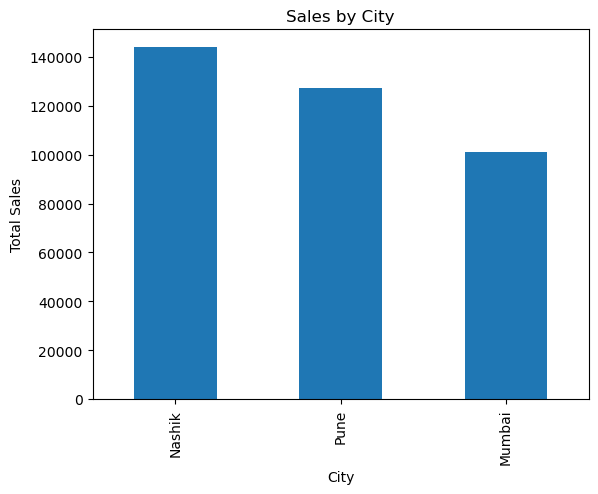

In [43]:
import matplotlib.pyplot as plt

city_sales.sort_values(ascending=False).plot(kind="bar")

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.show()

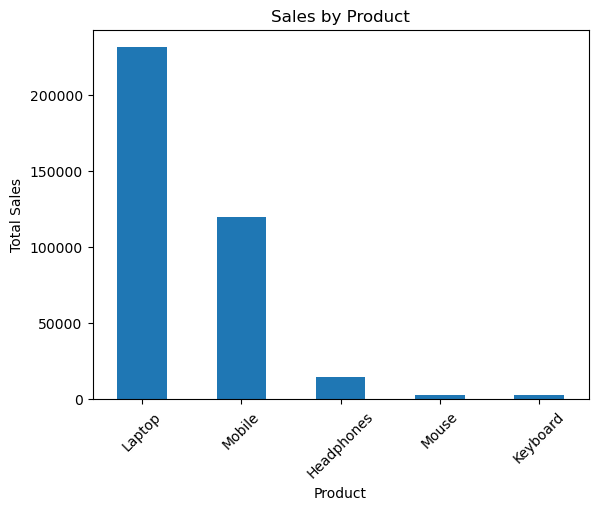

In [44]:
import matplotlib.pyplot as plt

product_sales.sort_values(ascending=False).plot(kind="bar")

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [45]:
product_rating = df.groupby("Product")["Rating"].mean()
product_rating

Product
Headphones    3.5
Keyboard      4.0
Laptop        5.0
Mobile        4.0
Mouse         3.0
Name: Rating, dtype: float64

In [48]:
customer_sales=df.groupby("Customer")["Sales"].sum()
customer_sales

Customer
Amit      66200
Karan      9000
Neha      22000
Priya     50000
Rahul    122000
Sneha    103000
Name: Sales, dtype: int64

In [49]:
customer_sales.sort_values(ascending=False)

Customer
Rahul    122000
Sneha    103000
Amit      66200
Priya     50000
Neha      22000
Karan      9000
Name: Sales, dtype: int64

In [50]:
customer_sales.sort_values(ascending=False).index[0]

'Rahul'

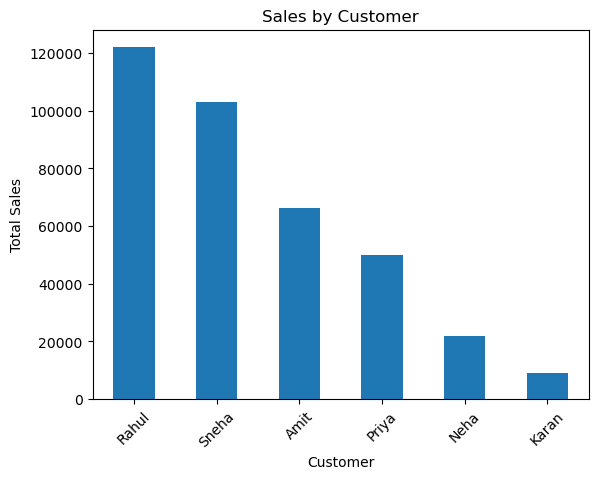

In [51]:
customer_sales.sort_values(ascending=False).plot(kind="bar")

plt.title("Sales by Customer")
plt.xlabel("Customer")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [53]:
total_sales=df["Sales"].sum()
total_sales

np.int64(372200)

In [55]:
total_quantity=df["Quantity"].sum()
total_quantity

np.int64(21)

In [57]:
unique_product=df["Product"].nunique()
unique_product

5

In [59]:
unique_customer=df["Customer"].nunique()
unique_customer

6

In [60]:
average_order_value = df["Sales"].mean()
average_order_value

np.float64(37220.0)

In [62]:
df["Quantity"].corr(df["Sales"])

np.float64(-0.47455414820574376)

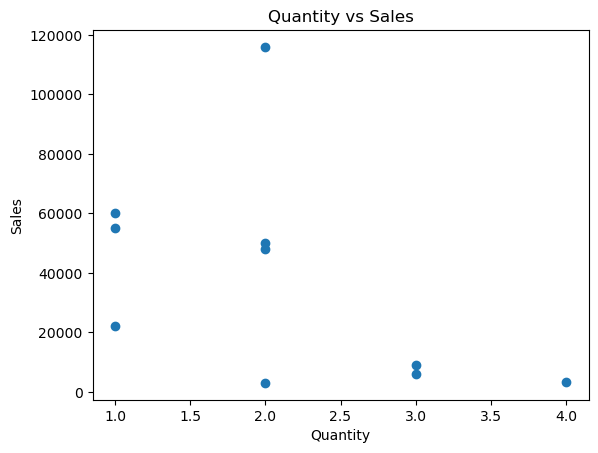

In [63]:
plt.scatter(df["Quantity"], df["Sales"])

plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")

plt.show()

In [64]:
summary = {
    "Total Revenue": df["Sales"].sum(),
    "Total Quantity Sold": df["Quantity"].sum(),
    "Average Order Value": df["Sales"].mean(),
    "Unique Customers": df["Customer"].nunique(),
    "Unique Products": df["Product"].nunique()
}

summary

{'Total Revenue': np.int64(372200),
 'Total Quantity Sold': np.int64(21),
 'Average Order Value': np.float64(37220.0),
 'Unique Customers': 6,
 'Unique Products': 5}

In [65]:
corr = df[["Quantity", "Price", "Rating", "Sales"]].corr()

corr

,Quantity,Price,Rating,Sales
Quantity,1.000000,-0.711117,-0.772284,-0.474554
Price,-0.711117,1.000000,0.887764,0.875913
Rating,-0.772284,0.887764,1.000000,0.759925
Sales,-0.474554,0.875913,0.759925,1.000000


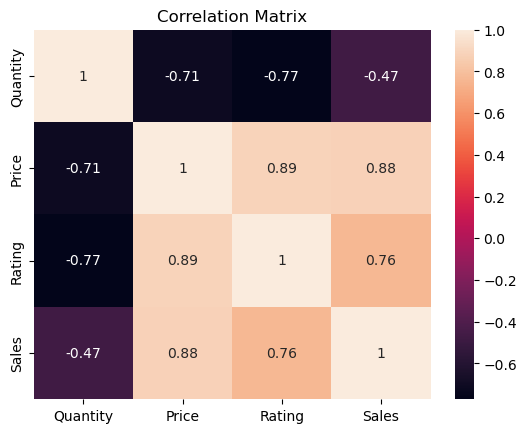

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")
plt.show()

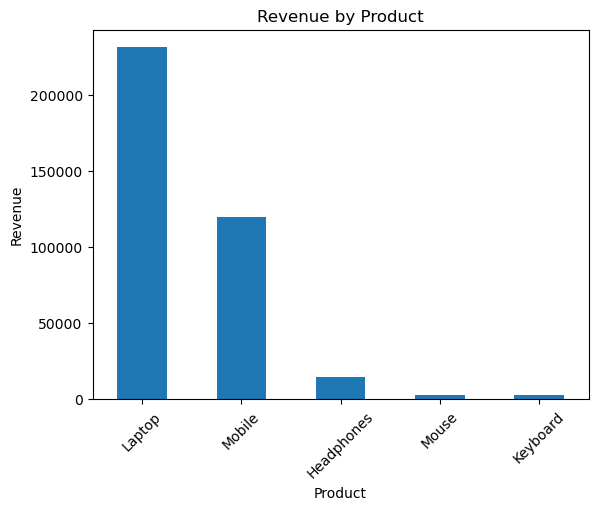

In [67]:
product_sales.sort_values(ascending=False).plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

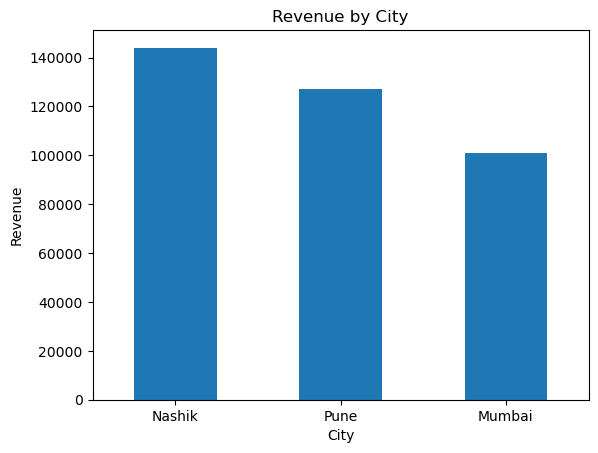

In [68]:
city_sales.sort_values(ascending=False).plot(kind="bar")

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

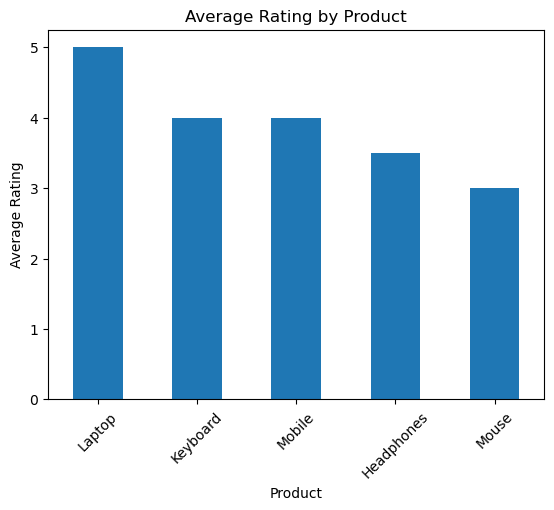

In [69]:
product_rating = df.groupby("Product")["Rating"].mean()

product_rating.sort_values(ascending=False).plot(kind="bar")

plt.title("Average Rating by Product")
plt.xlabel("Product")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

In [70]:
final_summary = df.groupby("Product").agg(
    Total_Sales=("Sales", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Average_Rating=("Rating", "mean")
)

final_summary = final_summary.sort_values(
    "Total_Sales",
    ascending=False
)

final_summary

,Total_Sales,Total_Quantity,Average_Rating
Product,,,
Laptop,231000,4,5.0
Mobile,120000,5,4.0
Headphones,15000,6,3.5
Mouse,3200,4,3.0
Keyboard,3000,2,4.0
